## Setup

In [2]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
BACKEND = ROOT / 'backend'
if str(BACKEND) not in sys.path:
    sys.path.append(str(BACKEND))


In [3]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /Users/hamza/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/hamza/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
import src.pdf_reader as pdf_reader
import src.text_processor as text_processor
import src.vocab_builder as vocab_builder
import src.example_extractor as example_extractor
import src.vocab_ranker as vocab_ranker
import src.definition_extractor as definition_extractor


importlib.reload(pdf_reader)
importlib.reload(text_processor)
importlib.reload(vocab_builder)
importlib.reload(example_extractor)
importlib.reload(vocab_ranker)
importlib.reload(definition_extractor)

from src.pdf_reader import extract_text_from_pdf
from src.text_processor import process_text
from src.vocab_builder import build_vocabulary
from src.example_extractor import add_example_sentences
from src.vocab_ranker import rank_vocabulary
from src.definition_extractor import add_definitions



## Config

In [6]:
BOOK_PATH = "../backend/data/raw/book.pdf"
MIN_FREQUENCY = 2
TOP_N = 20


## Read the PDF

In [7]:
text = extract_text_from_pdf(BOOK_PATH)

print(text[:1500])



PRAISE FOR
A COUNTRY DOCTOR’S NOTEBOOK
“This book has a freshness and liveliness … an epic quality because of the background 
Russia’s vastness, the great distances, the weight of the ignorance, the need.”
—DORIS LESSI
“These straightforward yet extraordinary sketches gain their strength from also being th
account of a young man’s growth. One begins to see that he became a novelist not becau
he had material but because he was storing up passion and temperament.”
—V.S. PRITCHETT, NEW STATESM
“Stories as keen and bright as a scalpel … Courage shines from every angle of th
profoundly human collection by the greatest of modern Russian writers.”
—SUNDAY TIM
“Bulgakov casts a wonderfully wry, self-deprecating humour. His compassion for huma
folly is unfailing … These stories stand testament both to human resilience and 
remarkable literary talent.”
—THE INDEPENDE

A COUNTRY DOCTOR’S NOTEBOOK
MIKHAIL BULGAKOV (1891–1940) was born in Kiev, one of seven children born to a
university lecturer a

Quick check just to make sure the text extraction looks normal before doing anything else.

##  Process the text

In [8]:
tokens = process_text(text)

len(tokens)


47326

In [9]:
tokens[:20]


[{'word': 'praise',
  'lemma': 'praise',
  'pos': 'VERB',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'for',
  'lemma': 'for',
  'pos': 'ADP',
  'is_stop': True,
  'ent_type': '',
  'is_title': False},
 {'word': 'a',
  'lemma': 'a',
  'pos': 'DET',
  'is_stop': True,
  'ent_type': '',
  'is_title': True},
 {'word': 'country',
  'lemma': 'country',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'doctor',
  'lemma': 'doctor',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'notebook',
  'lemma': 'notebook',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'this',
  'lemma': 'this',
  'pos': 'DET',
  'is_stop': True,
  'ent_type': '',
  'is_title': True},
 {'word': 'book',
  'lemma': 'book',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'has',
  'lemma': 'have',
  'pos': 'VERB',
  'is_stop': True,
  'ent_typ

In [10]:
vocab_df = build_vocabulary(tokens, min_frequency=MIN_FREQUENCY)

vocab_df.head(30)


,lemma,pos,frequency
0,say,VERB,173
1,come,VERB,145
2,woman,NOUN,126
3,doctor,NOUN,120
4,eye,NOUN,112
5,time,NOUN,105
6,look,VERB,94
7,feel,VERB,91
8,think,VERB,91
9,man,NOUN,82


In [11]:
vocab_df.shape

(2304, 3)

In [12]:
vocab_df.sample(20)


,lemma,pos,frequency
13,little,ADJ,70
1302,obstetric,NOUN,3
1305,occasionally,ADV,3
1767,fog,NOUN,2
936,inspire,VERB,4
1000,proper,ADJ,4
230,air,NOUN,13
548,strange,ADJ,7
634,row,NOUN,6
252,thank,VERB,13


## Basic inspection

In [13]:
vocab_df["frequency"].describe()


count    2304.000000
mean        6.818576
std        11.329896
min         2.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       173.000000
Name: frequency, dtype: float64

In [14]:
vocab_df["pos"].value_counts()


pos
NOUN    1104
VERB     638
ADJ      403
ADV      159
Name: count, dtype: int64

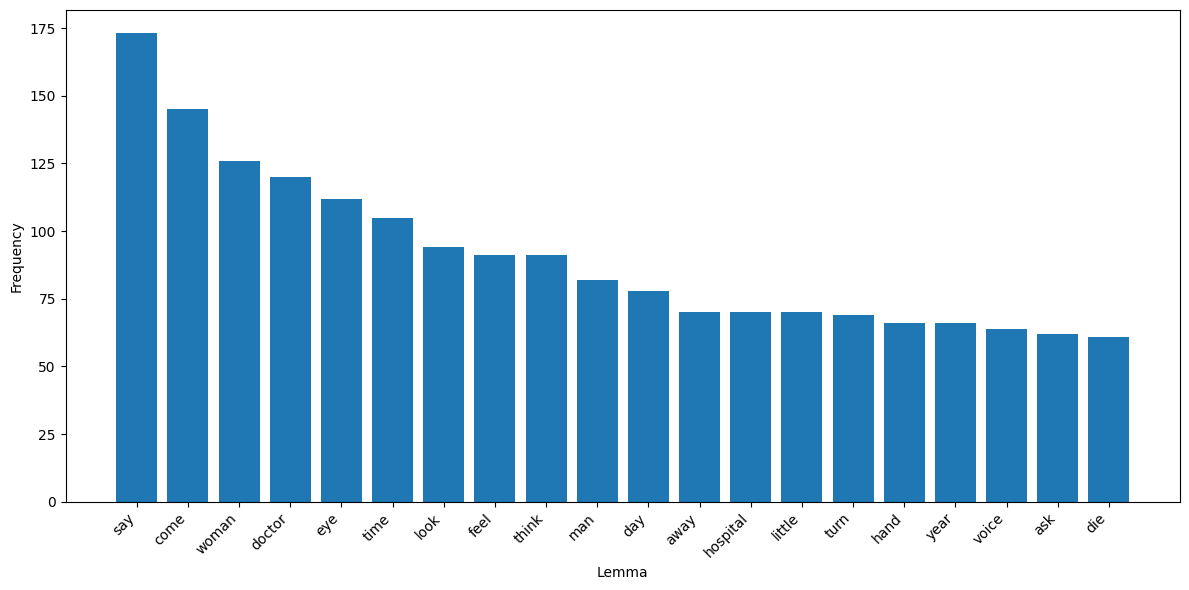

In [15]:
top_vocab = vocab_df.head(TOP_N)

plt.figure(figsize=(12, 6))
plt.bar(top_vocab["lemma"], top_vocab["frequency"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


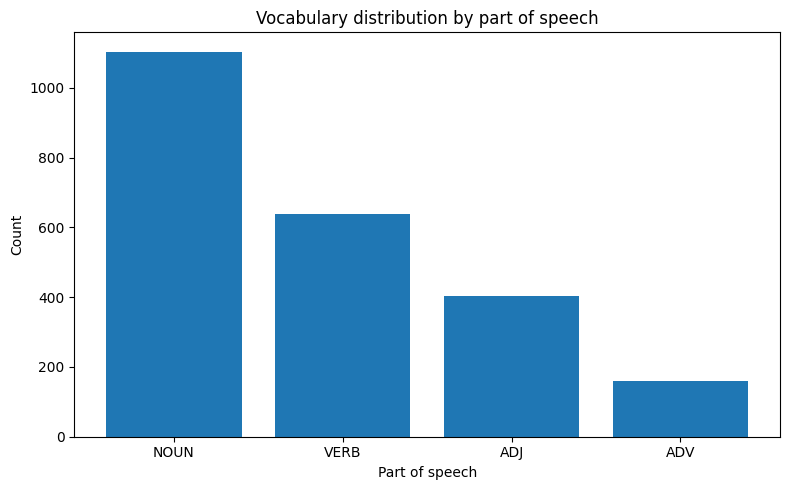

In [16]:
pos_counts = vocab_df["pos"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(pos_counts.index, pos_counts.values)
plt.xlabel("Part of speech")
plt.ylabel("Count")
plt.title("Vocabulary distribution by part of speech")
plt.tight_layout()
plt.show()


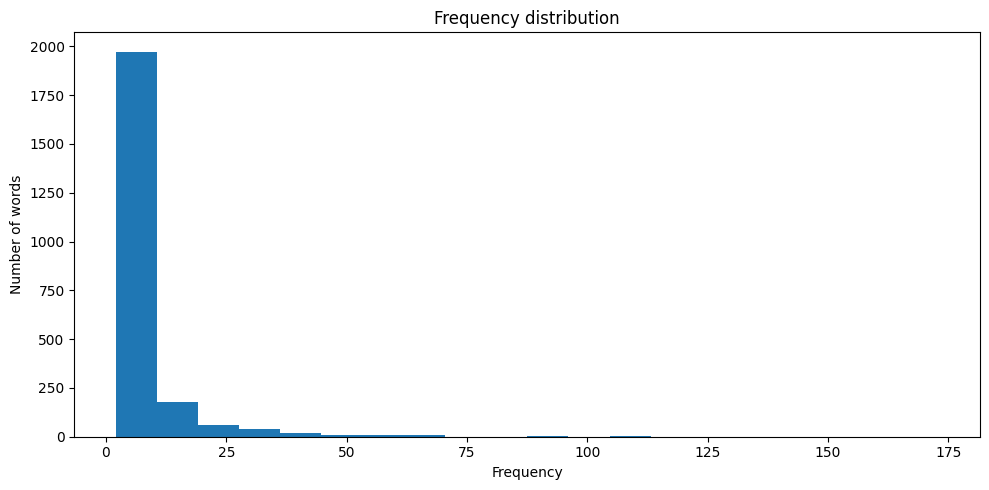

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(vocab_df["frequency"], bins=20)
plt.xlabel("Frequency")
plt.ylabel("Number of words")
plt.title("Frequency distribution")
plt.tight_layout()
plt.show()


## Adding example sentences

In [18]:
vocab_with_examples = add_example_sentences(vocab_df, text)

vocab_with_examples[["lemma", "frequency", "example_sentence"]].head(20)


,lemma,frequency,example_sentence
0,say,173,Do you know what they ’re **saying** in the vi...
1,come,145,I turned round and saw that a round - faced ol...
2,woman,126,I turned round and saw that a round - faced ol...
3,doctor,120,A few minutes later I was standing beside the ...
4,eye,112,I raised her cold eyelid and looked with super...
5,time,105,All the **time** a ɹne rain was drizzling down...
6,look,94,And as you die a slow death there ’s nothing t...
7,feel,91,Thereupon I regained my wits and started **fee...
8,think,91,Just **think** … I actually had to put up for ...
9,man,82,and I saw a **man** hobbling towards me in a r...


In [19]:
vocab_with_examples.sample(10)


,lemma,pos,frequency,example_sentence,example_source
1409,soft,ADJ,3,And best of all I can make the music louder or...,good
1160,crash,NOUN,3,The feldsher collapsed to the ɻoor with a **cr...,good
253,wonder,VERB,13,A moment later I began to **wonder** — where w...,good
1000,proper,ADJ,4,I had not had a **proper** wash for a month.,good
20,begin,VERB,60,‘ But say it **begins**? ’ ‘ I ca n’t understa...,good
2235,tremendous,ADJ,2,It is books like this which make one appreciat...,good
1319,perish,VERB,3,"We did not **perish**, nor did we lose our way...",good
1397,sledge,NOUN,3,The letter set oʃ on its twenty - ɹve - mile j...,good
755,jump,VERB,5,"I started reading the text, but could take non...",good
1337,pretty,ADV,3,‘ Is she **pretty**? ’ ‘ Prettiest girl for mi...,good


In [20]:
vocab_with_examples["example_sentence"].isna().sum()


np.int64(0)

This is the part I mostly care about when checking quality. If the examples look weird, I need to improve the filtering or sentence scoring.

## Rank the vocabulary

In [21]:
ranked_vocab_df = rank_vocabulary(vocab_with_examples)

ranked_vocab_df[["lemma", "pos", "frequency", "zipf_frequency", "vocab_score", "example_sentence"]].head(30)


,lemma,pos,frequency,zipf_frequency,vocab_score,example_sentence
0,sleigh,NOUN,29,2.99,17.039999,I could hear the creaking of **sleigh** - runn...
1,hoarse,ADJ,13,2.66,16.206451,‘ “ A deserter? ” croaked the now familiar **h...
2,morphine,NOUN,32,3.37,16.188830,The **morphine** worked sooner than I had expe...
3,midwife,NOUN,28,3.27,15.927309,A **midwife** took a firm hold of the old woma...
4,gauze,NOUN,20,2.89,15.557510,Lying on a piece of **gauze** on the table was...
5,sheepskin,NOUN,15,2.50,15.249238,Where are you from? ’ The **sheepskin** coat f...
6,doctor,NOUN,120,4.90,14.866951,A few minutes later I was standing beside the ...
7,gramme,NOUN,9,1.64,14.644441,There were only two syringes — a small one- **...
8,lamp,NOUN,38,4.05,14.471069,The pressure - **lamp** with its lopsided tin ...
9,syrinx,NOUN,9,1.83,14.206950,There were only two **syringes** — a small one...


In [22]:
ranked_vocab_df[["lemma", "frequency", "zipf_frequency", "vocab_score"]].sample(20)


,lemma,frequency,zipf_frequency,vocab_score
2251,round,2,5.14,3.142031
895,wit,4,3.96,6.502129
794,samovar,2,1.88,6.723507
821,thank,13,5.48,6.650424
778,surround,4,3.79,6.775734
1908,sweat,2,4.14,4.240643
1889,cause,4,5.35,4.265010
882,boy,9,5.17,6.516316
745,wife,11,5.23,6.883191
816,thrust,4,3.86,6.663073


In [23]:
ranked_vocab_df["zipf_frequency"].describe()


count    2304.000000
mean        4.217565
std         0.983460
min         0.000000
25%         3.680000
50%         4.370000
75%         4.920000
max         6.710000
Name: zipf_frequency, dtype: float64

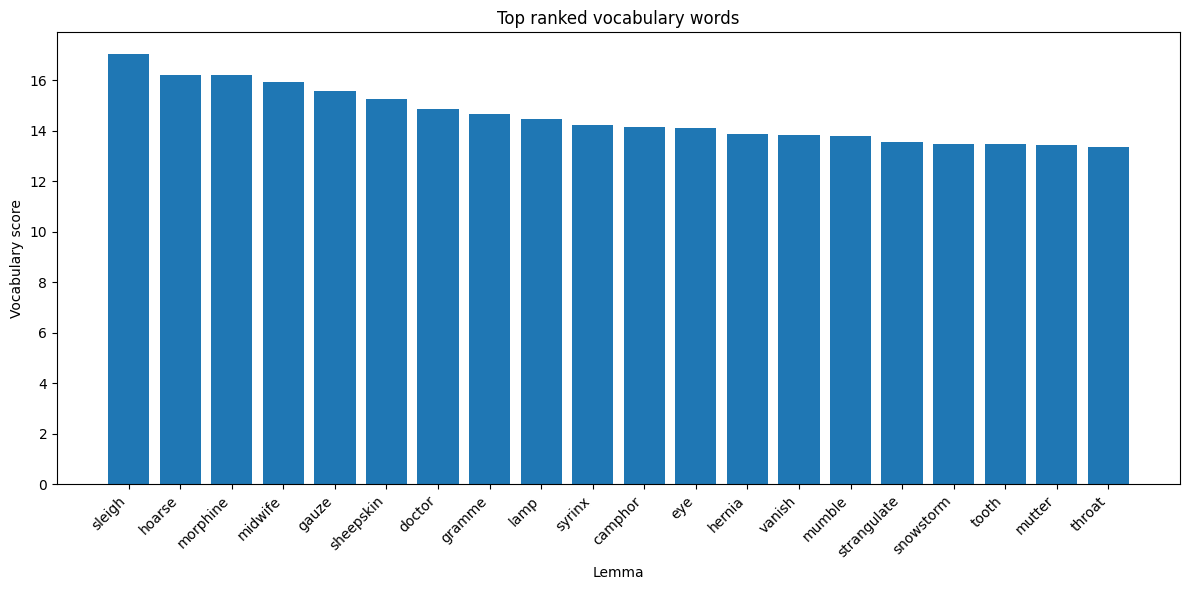

In [24]:
top_ranked = ranked_vocab_df.head(TOP_N)

plt.figure(figsize=(12, 6))
plt.bar(top_ranked["lemma"], top_ranked["vocab_score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Vocabulary score")
plt.title("Top ranked vocabulary words")
plt.tight_layout()
plt.show()


In [25]:
vocab_with_definitions = add_definitions(ranked_vocab_df)
vocab_with_definitions[
    ["lemma", "pos", "frequency", "definition", "example_sentence"]
].head(20)

,lemma,pos,frequency,definition,example_sentence
0,sleigh,NOUN,29,a vehicle mounted on runners and pulled by hor...,I could hear the creaking of **sleigh** - runn...
1,hoarse,ADJ,13,deep and harsh sounding as if from shouting or...,‘ “ A deserter? ” croaked the now familiar **h...
2,morphine,NOUN,32,an alkaloid narcotic drug extracted from opium...,The **morphine** worked sooner than I had expe...
3,midwife,NOUN,28,a woman skilled in aiding the delivery of babies,A **midwife** took a firm hold of the old woma...
4,gauze,NOUN,20,(medicine) bleached cotton cloth of plain weav...,Lying on a piece of **gauze** on the table was...
5,sheepskin,NOUN,15,tanned skin of a sheep with the fleece left on...,Where are you from? ’ The **sheepskin** coat f...
6,doctor,NOUN,120,a licensed medical practitioner,A few minutes later I was standing beside the ...
7,gramme,NOUN,9,a metric unit of weight equal to one thousandt...,There were only two syringes — a small one- **...
8,lamp,NOUN,38,an artificial source of visible illumination,The pressure - **lamp** with its lopsided tin ...
9,syrinx,NOUN,9,a primitive wind instrument consisting of seve...,There were only two **syringes** — a small one...


##  Export

In [26]:
# vocab_with_examples.to_csv("../backend/outputs/vocabulary_with_examples.csv", index=False)
# ranked_vocab_df.to_csv("../backend/outputs/ranked_vocabulary.csv", index=False)
# vocab_with_definitions.to_csv("../backend/outputs/vocabulary_with_definitions.csv", index=False)


In [27]:
study_df = vocab_with_definitions[
    ["lemma", "pos", "frequency", "zipf_frequency", "vocab_score","definition" ,"example_sentence"]
].copy()

study_df.head(20)


,lemma,pos,frequency,zipf_frequency,vocab_score,definition,example_sentence
0,sleigh,NOUN,29,2.99,17.039999,a vehicle mounted on runners and pulled by hor...,I could hear the creaking of **sleigh** - runn...
1,hoarse,ADJ,13,2.66,16.206451,deep and harsh sounding as if from shouting or...,‘ “ A deserter? ” croaked the now familiar **h...
2,morphine,NOUN,32,3.37,16.188830,an alkaloid narcotic drug extracted from opium...,The **morphine** worked sooner than I had expe...
3,midwife,NOUN,28,3.27,15.927309,a woman skilled in aiding the delivery of babies,A **midwife** took a firm hold of the old woma...
4,gauze,NOUN,20,2.89,15.557510,(medicine) bleached cotton cloth of plain weav...,Lying on a piece of **gauze** on the table was...
5,sheepskin,NOUN,15,2.50,15.249238,tanned skin of a sheep with the fleece left on...,Where are you from? ’ The **sheepskin** coat f...
6,doctor,NOUN,120,4.90,14.866951,a licensed medical practitioner,A few minutes later I was standing beside the ...
7,gramme,NOUN,9,1.64,14.644441,a metric unit of weight equal to one thousandt...,There were only two syringes — a small one- **...
8,lamp,NOUN,38,4.05,14.471069,an artificial source of visible illumination,The pressure - **lamp** with its lopsided tin ...
9,syrinx,NOUN,9,1.83,14.206950,a primitive wind instrument consisting of seve...,There were only two **syringes** — a small one...


In [28]:
len(study_df)

2304

In [29]:
vocab_with_definitions[vocab_with_definitions["definition"].isna()].count()

lemma                   0
pos                     0
frequency               0
example_sentence        0
example_source          0
zipf_frequency          0
book_frequency_score    0
rarity_score            0
pos_weight              0
vocab_score             0
difficulty              0
definition              0
dtype: int64

In [30]:
vocab_with_definitions[vocab_with_definitions["definition"].isna()].head(20)

,lemma,pos,frequency,example_sentence,example_source,zipf_frequency,book_frequency_score,rarity_score,pos_weight,vocab_score,difficulty,definition
